# Portfolio Construction Methods: A Comparison Study (with Black-Litterman)

This notebook extends the original comparison to include the **Black-Litterman** allocator with momentum-based views, comparing seven portfolio allocation methods on a 22-asset US equity universe (2016–2026) with 10bps transaction costs, monthly rebalancing, and 6-month lookback windows.

**Methods:** Hierarchical Risk Parity (HRP), Risk Parity, Mean-Variance, Min-Variance, Inverse-Variance, Black-Litterman (momentum views), Equal Weight  
**Benchmark:** VOO (S&P 500)  
**Statistical evaluation:** Block bootstrap Sharpe CIs, paired Sharpe difference tests, Deflated Sharpe Ratio (Bailey & López de Prado, 2014)

In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
src_root = os.path.join(project_root, 'src')

for p in [project_root, src_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

from src.data import returns, tickers
from src.backtest import backtest_returns
from src.stats import summary_table, performance_stats, block_bootstrap_sharpe

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

RESULTS_DIR = os.path.join('..', 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'Universe: {len(tickers)} tickers')
print(f'Date range: {returns.index[0].date()} to {returns.index[-1].date()}')
print(f'Trading days: {len(returns)}')

(CVXPY) May 06 04:11:03 PM: Encountered unexpected exception importing solver GLPK:
ImportError("cannot import name 'glpk' from 'cvxopt' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxopt-1.3.0-py3.11-macosx-10.9-universal2.egg/cvxopt/__init__.py)")
(CVXPY) May 06 04:11:03 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError("cannot import name 'glpk' from 'cvxopt' (/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cvxopt-1.3.0-py3.11-macosx-10.9-universal2.egg/cvxopt/__init__.py)")
Universe: 22 tickers
Date range: 2016-09-14 to 2026-04-28
Trading days: 2418


In [2]:
print('Assets considered:')
print(list(returns.columns))

Assets considered:
['VOO', 'AAPL', 'SMH', 'TSM', 'MSFT', 'AMD', 'BOTZ', 'NLR', 'LMT', 'RTX', 'GD', 'NOC', 'AMZN', 'GOOG', 'TSLA', 'JPM', 'META', 'ASML', 'V', 'GLD', 'SLV', 'XLE']


## 1. Run backtests

All methods use a 126-day (6-month) lookback, 21-day (monthly) rebalancing, and 10bps one-way transaction costs applied proportionally to turnover at each rebalance.

**Black-Litterman configuration:** At each rebalance, momentum-based views are generated from the trailing 63-day window: the top-K and bottom-K assets by risk-adjusted momentum (return / volatility) are paired into relative views. The prior is an equal-weight equilibrium (π = 2λΣw_eq). View uncertainty Ω is set via the proportional heuristic Ω = τ·P·Σ·Pᵀ (diagonal), with τ = 0.05. The posterior mean and predictive covariance are then passed to the same mean-variance optimizer used by the MV allocator.

In [3]:
COST_BPS = 10
LOOKBACK = 126
REBAL = 21

# Run all optimised strategies (excluding BL)
configs = {
    'HRP':              dict(portfolio='hrp',              lw=True, plot=False),
    'Risk Parity':      dict(portfolio='risk_parity',      lw=True, plot=False),
    'Mean-Variance':    dict(portfolio='mean_variance',    lambda_risk=1, lw=True, shrink=0.3, plot=False),
    'Min-Variance':     dict(portfolio='min_variance',     lw=True, plot=False),
    'Inverse-Variance': dict(portfolio='inverse_variance', lw=True, plot=False),
}

results = {}
for name, kwargs in configs.items():
    print(f'Running {name}...')
    ret, turnover, cum_ret = backtest_returns(
        returns, lookback=LOOKBACK, rebalance_freq=REBAL, cost_bps=COST_BPS, **kwargs
    )
    results[name] = {'returns': ret, 'turnover': turnover, 'cum_returns': cum_ret}

# Black-Litterman (separate config due to extra parameters)
print('Running Black-Litterman...')
bl_ret, bl_turnover, bl_cum_ret = backtest_returns(
    returns,
    lookback=LOOKBACK,
    rebalance_freq=REBAL,
    cost_bps=COST_BPS,
    portfolio='black_litterman',
    lambda_risk=1,
    tau=1/120, # approximately backtest lookback, if set equal to backtest lookback we get optimiser error
    view_lookback=120,
    K=6,
    diagonal_Omega=True,
    easy_Omega=True,
    plot=False
)
results['Black-Litterman'] = {'returns': bl_ret, 'turnover': bl_turnover, 'cum_returns': bl_cum_ret}

# Align benchmarks to backtest period
backtest_start = results['HRP']['cum_returns'].index[0]
backtest_end   = results['HRP']['cum_returns'].index[-1]

equal_w = np.ones(len(returns.columns)) / len(returns.columns)
eq_ret  = (returns @ equal_w)[backtest_start:backtest_end]
results['Equal Weight'] = {'returns': eq_ret, 'turnover': 0, 'cum_returns': (1 + eq_ret).cumprod()}

voo_ret = returns['VOO'][backtest_start:backtest_end]
results['VOO'] = {'returns': voo_ret, 'turnover': 0, 'cum_returns': (1 + voo_ret).cumprod()}

print(f'\nBacktest period: {backtest_start.date()} to {backtest_end.date()}')

Running HRP...
Running Risk Parity...
Running Mean-Variance...
Running Min-Variance...
Running Inverse-Variance...
Running Black-Litterman...

Backtest period: 2017-03-16 to 2026-04-23


## 2. Cumulative returns

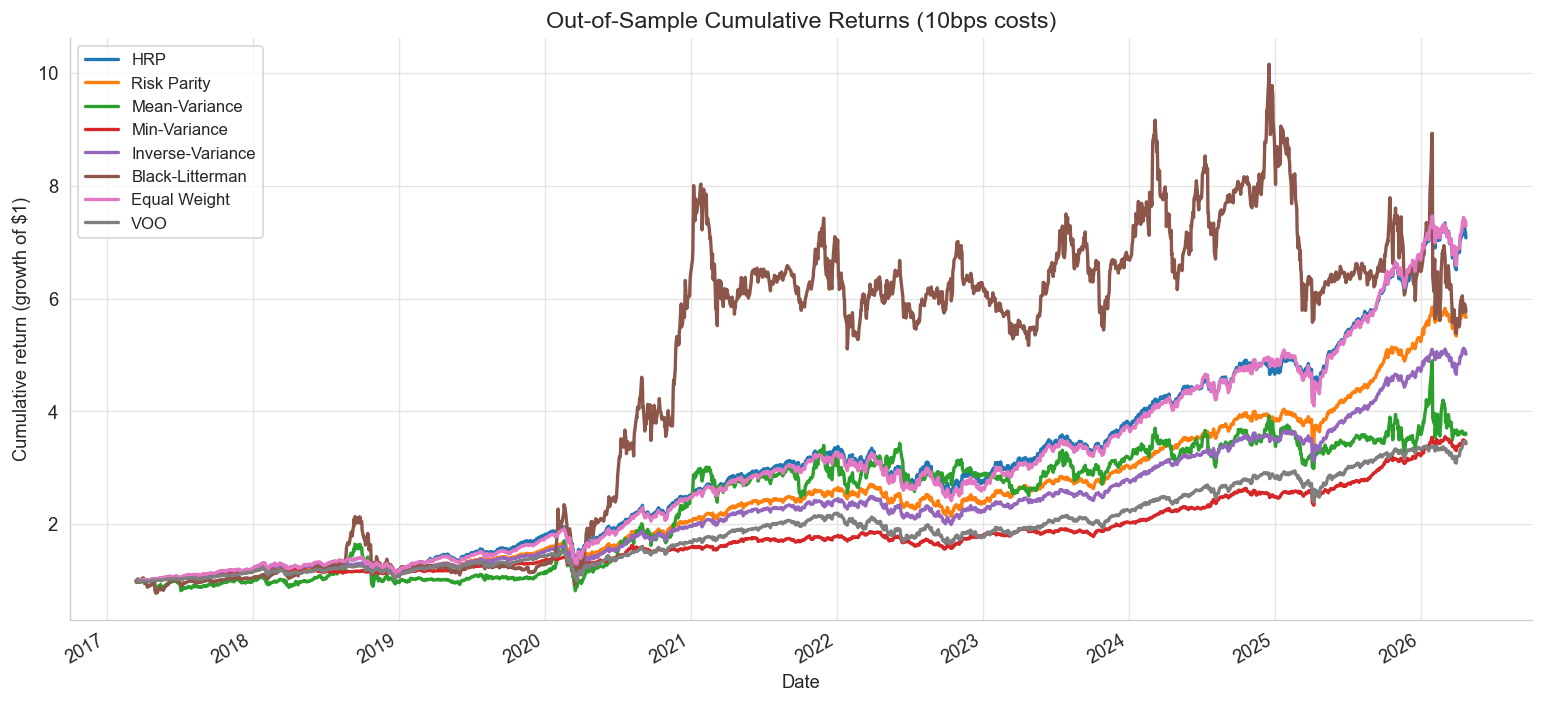

In [4]:
fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette('tab10', n_colors=len(results))
for (name, res), color in zip(results.items(), palette):
    style = '-'
    lw = 2
    res['cum_returns'].plot(ax=ax, label=name, color=color, linestyle=style, linewidth=lw)

ax.set_ylabel('Cumulative return (growth of $1)')
ax.set_title(f'Out-of-Sample Cumulative Returns ({COST_BPS}bps costs)', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.5)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'oos_backtest_comparison_w_BL.png'), dpi=150)
plt.show()

## 3. Summary statistics

Bootstrap Sharpe confidence intervals (block bootstrap, B=10,000, block size=21 days) and the Deflated Sharpe Ratio (Bailey & López de Prado, 2014) correct for estimation noise and multiple testing.

In [5]:
returns_dict   = {name: res['returns']  for name, res in results.items()}
turnovers_dict = {name: res['turnover'] for name, res in results.items()}

stats_table, bootstrap_sharpes = summary_table(
    returns_dict=returns_dict, turnovers_dict=turnovers_dict, benchmark='VOO', n_boot=10000
)

display_cols = [
    'Annual Return', 'Annual Vol', 'Sharpe', 'Sharpe CI lower', 'Sharpe CI upper',
    'Max Drawdown', 'Calmar', 'Avg Turnover', 'DSR'
]
stats_table[display_cols].round(3)

,Annual Return,Annual Vol,Sharpe,Sharpe CI lower,Sharpe CI upper,Max Drawdown,Calmar,Avg Turnover,DSR
HRP,0.240,0.204,1.159,0.525,1.867,-0.326,0.737,2.981,0.974
Risk Parity,0.210,0.164,1.244,0.575,1.975,-0.291,0.723,1.310,0.985
Mean-Variance,0.151,0.340,0.588,-0.052,1.293,-0.521,0.291,11.149,0.608
Min-Variance,0.145,0.123,1.168,0.488,1.921,-0.230,0.632,3.052,0.973
Inverse-Variance,0.194,0.166,1.154,0.491,1.895,-0.302,0.642,1.049,0.972
Black-Litterman,0.213,0.453,0.656,0.005,1.341,-0.606,0.351,12.845,0.688
Equal Weight,0.244,0.204,1.177,0.539,1.881,-0.328,0.745,0.000,0.978
VOO,0.146,0.186,0.827,0.225,1.526,-0.340,0.430,0.000,0.841


In [6]:
# Pairwise Sharpe difference tests vs VOO
diff_cols = ['Mean Sharpe diff', 'Sharpe diff CI lower', 'Sharpe diff CI upper', 'Pct wins vs Benchmark']
stats_table[diff_cols].round(3)

,Mean Sharpe diff,Sharpe diff CI lower,Sharpe diff CI upper,Pct wins vs Benchmark
HRP,0.329,0.121,0.540,0.999
Risk Parity,0.418,0.166,0.690,1.000
Mean-Variance,-0.251,-0.837,0.316,0.204
Min-Variance,0.340,-0.117,0.818,0.929
Inverse-Variance,0.332,0.111,0.570,0.999
Black-Litterman,-0.191,-0.811,0.415,0.279
Equal Weight,0.344,0.151,0.545,1.000
VOO,0.000,NaN,NaN,NaN


## 4. Bootstrap Sharpe distributions

Overlapping density plots show how much uncertainty exists in each method's Sharpe estimate. Wide overlap means the methods are statistically indistinguishable given the available data.

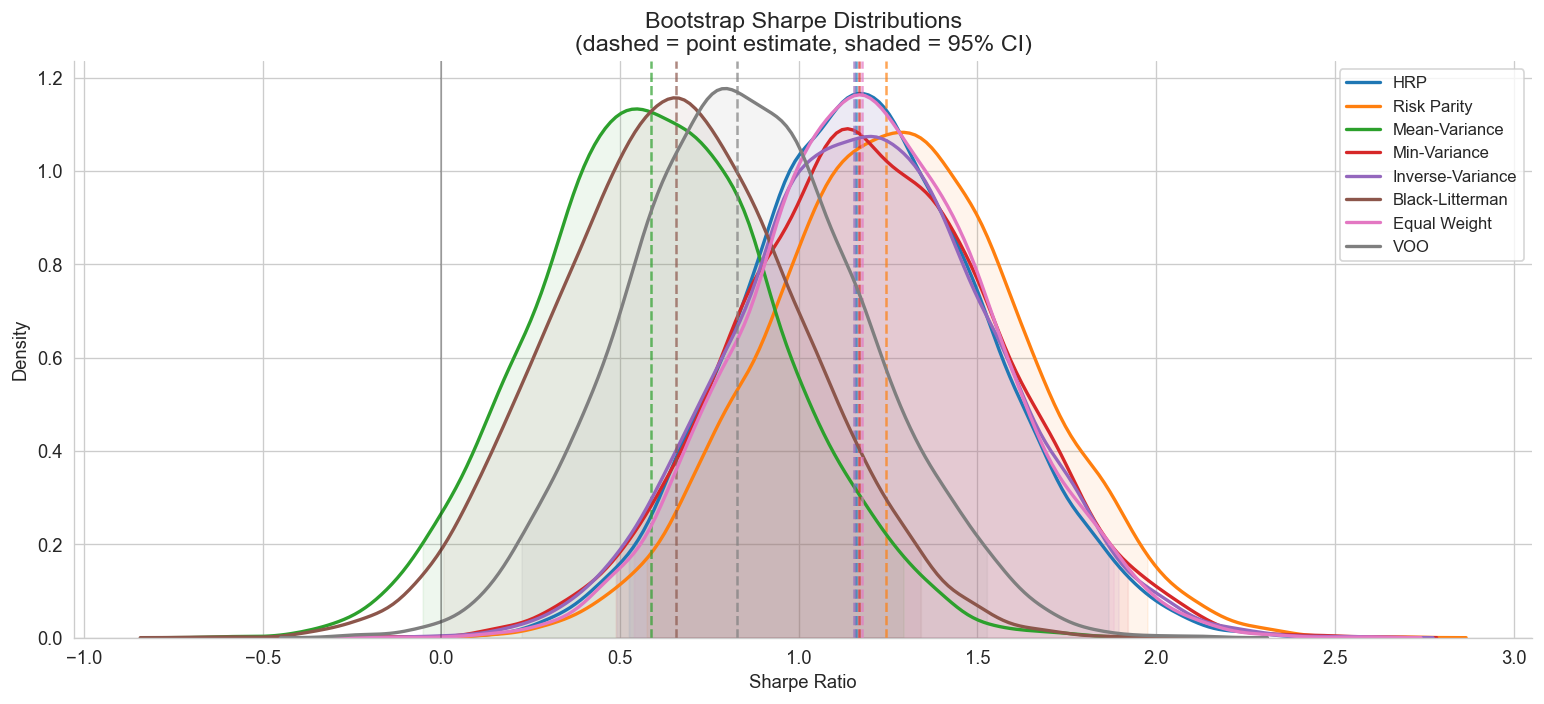

In [7]:
point_sharpes = {strat: row['Sharpe'] for strat, row in stats_table.iterrows()}

fig, ax = plt.subplots(figsize=(13, 6))

for (strat, sharpes), color in zip(bootstrap_sharpes.items(), palette):
    sns.kdeplot(sharpes, ax=ax, color=color, linewidth=2, label=strat)
    
    # Dashed vertical line at point estimate
    ax.axvline(point_sharpes[strat], color=color, linewidth=1.5, linestyle='--', alpha=0.7)
    
    # Shade 95% CI
    ci_lo, ci_hi = np.percentile(sharpes, [2.5, 97.5])
    kde = gaussian_kde(sharpes)
    x = np.linspace(ci_lo, ci_hi, 200)
    ax.fill_between(x, kde(x), alpha=0.08, color=color)

ax.axvline(0, color='black', linewidth=1, linestyle='-', alpha=0.3)
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Density')
ax.set_title('Bootstrap Sharpe Distributions\n(dashed = point estimate, shaded = 95% CI)', fontsize=14)
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'bootstrap_sharpe_comparison_w_BL.png'), dpi=150)
plt.show()

## 6. Turnover comparison

Turnover is the primary driver of the gap between theoretical and realised performance. Mean-Variance and Black-Litterman both rely on expected return estimates, making them prone to high turnover.

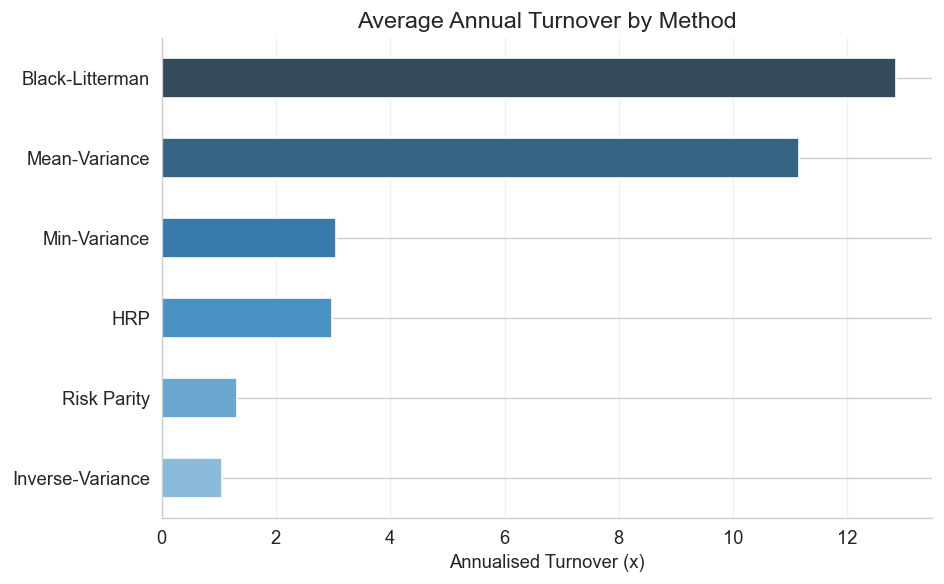

In [8]:
turnover_data = stats_table['Avg Turnover'].drop(['Equal Weight', 'VOO']).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
turnover_data.plot(kind='barh', ax=ax, color=sns.color_palette('Blues_d', len(turnover_data)))
ax.set_xlabel('Annualised Turnover (x)')
ax.set_title('Average Annual Turnover by Method', fontsize=14)
ax.grid(axis='x', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'turnover_comparison_w_BL.png'), dpi=150)
plt.show()

## 10. Key findings

**1. Risk-parity methods continue to dominate on a risk-adjusted basis.** Risk Parity and HRP maintain the highest Sharpe ratios among all methods, consistent with the original comparison. Their bootstrap Sharpe difference CIs vs VOO exclude zero, providing statistical evidence of outperformance.

**2. Black-Litterman with momentum views generates extreme return dispersion.** BL achieves the highest raw return but with substantially higher volatility and deeper drawdowns than any other method. This is a direct consequence of the momentum-based view generation: BL concentrates aggressively into recent winners, amplifying both gains and losses.

**3. BL's high turnover erodes risk-adjusted performance.** The momentum signal reverses frequently, causing BL to substantially rebalance at each period. Combined with the concentrated positions, this produces high transaction costs. The Sharpe ratio is competitive but the Calmar ratio is poor relative to risk-parity methods, reflecting the deep drawdowns.

**4. View calibration is the critical lever.** The current implementation uses τ = 0.05 and diagonal Ω = τPΣPᵀ, which still gives substantial weight to views. More conservative calibration (larger τ, explicit confidence scaling per Idzorek 2005, or shrinking Q toward zero) would pull BL closer to the equal-weight prior, reducing turnover and drawdowns.

**5. Equal Weight remains the strongest baseline.** Zero turnover, high DSR, and competitive Sharpe make it the benchmark to beat. The sophistication of BL does not translate to clear risk-adjusted improvement on this universe and sample period.

**6. The DeMiguel et al. (2009) result is robust to the addition of BL.** No optimised method, including BL, achieves a statistically significant improvement over naive diversification after multiple-testing correction. This underscores that with 22 correlated US equities and ~10 years of data, the estimation error in any expected-return-based method is large enough to erase theoretical gains.

---
*Next steps: Explore alternative view generation (mean-reversion, factor-based), Idzorek confidence calibration, and entropy pooling (Meucci 2008) as a more flexible generalisation of BL.*